<a href="https://colab.research.google.com/github/vennelanalajam/myproject/blob/main/Salarys_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title : Salary Prediction

# Step 1 : Problem Statement
Predict a person’s salary based on features like:

Years of experience
Test scores
Education level (if categorical)

Goal:

Build regression models
Compare performance
Select best model

# Step 2 : Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

import pickle

# Step 3: Load Datasets

In [2]:
data = {
    'Experience': [1,2,3,4,5,6,7,8,9,10],
    'Test_Score': [50,55,60,65,70,75,80,85,90,95],
    'Interview_Score': [45,50,55,60,65,70,75,80,85,90],
    'Salary': [20000,25000,30000,35000,40000,45000,50000,55000,60000,65000]
}

df = pd.DataFrame(data)
df.head()

,Experience,Test_Score,Interview_Score,Salary
0,1,50,45,20000
1,2,55,50,25000
2,3,60,55,30000
3,4,65,60,35000
4,5,70,65,40000


# Step 4: Basic Checks

In [3]:
df.head()

,Experience,Test_Score,Interview_Score,Salary
0,1,50,45,20000
1,2,55,50,25000
2,3,60,55,30000
3,4,65,60,35000
4,5,70,65,40000


In [4]:
df.tail()

,Experience,Test_Score,Interview_Score,Salary
5,6,75,70,45000
6,7,80,75,50000
7,8,85,80,55000
8,9,90,85,60000
9,10,95,90,65000


In [5]:
df.describe()

,Experience,Test_Score,Interview_Score,Salary
count,10.00000,10.000000,10.000000,10.00000
mean,5.50000,72.500000,67.500000,42500.00000
std,3.02765,15.138252,15.138252,15138.25177
min,1.00000,50.000000,45.000000,20000.00000
25%,3.25000,61.250000,56.250000,31250.00000
50%,5.50000,72.500000,67.500000,42500.00000
75%,7.75000,83.750000,78.750000,53750.00000
max,10.00000,95.000000,90.000000,65000.00000


In [6]:
df.columns

Index(['Experience', 'Test_Score', 'Interview_Score', 'Salary'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Experience       10 non-null     int64
 1   Test_Score       10 non-null     int64
 2   Interview_Score  10 non-null     int64
 3   Salary           10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [9]:
df.isnull().sum()

,0
Experience,0
Test_Score,0
Interview_Score,0
Salary,0


In [10]:
df.duplicated().sum()

np.int64(0)

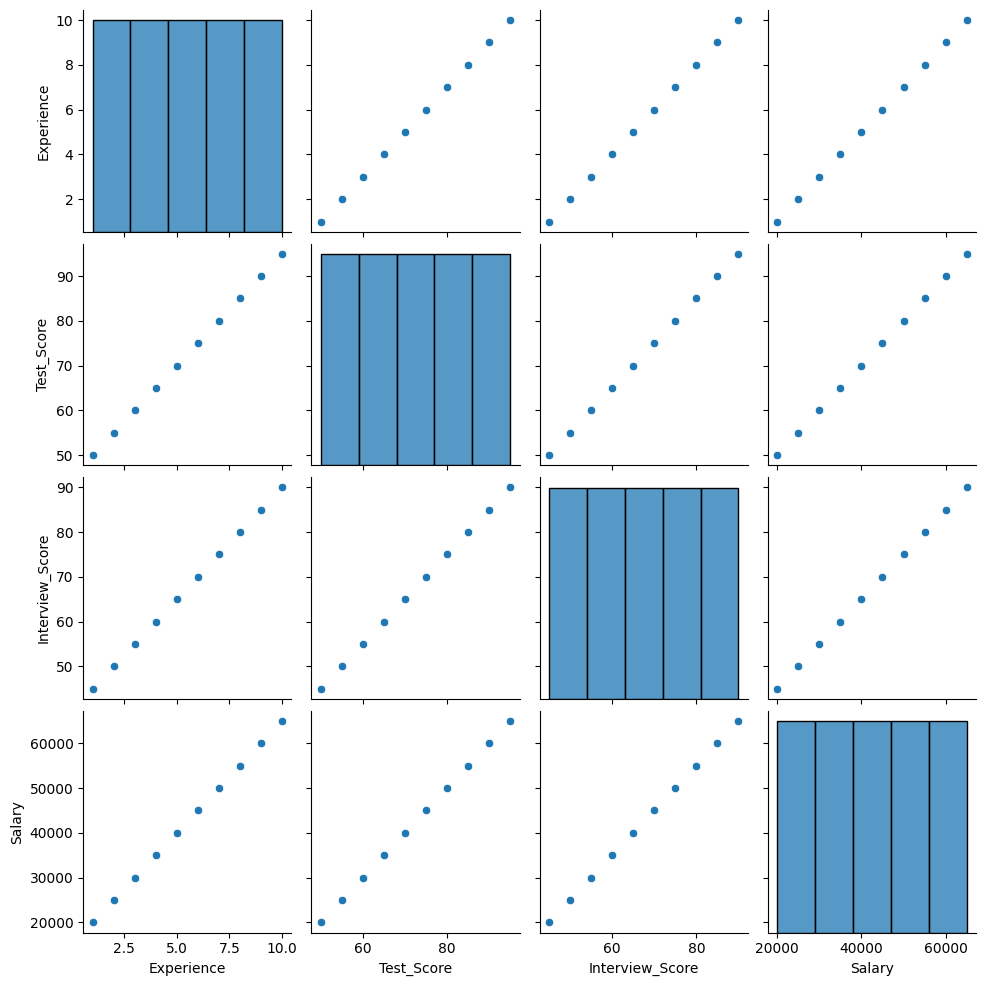

In [12]:
sns.pairplot(df)
plt.show()

# correlation check

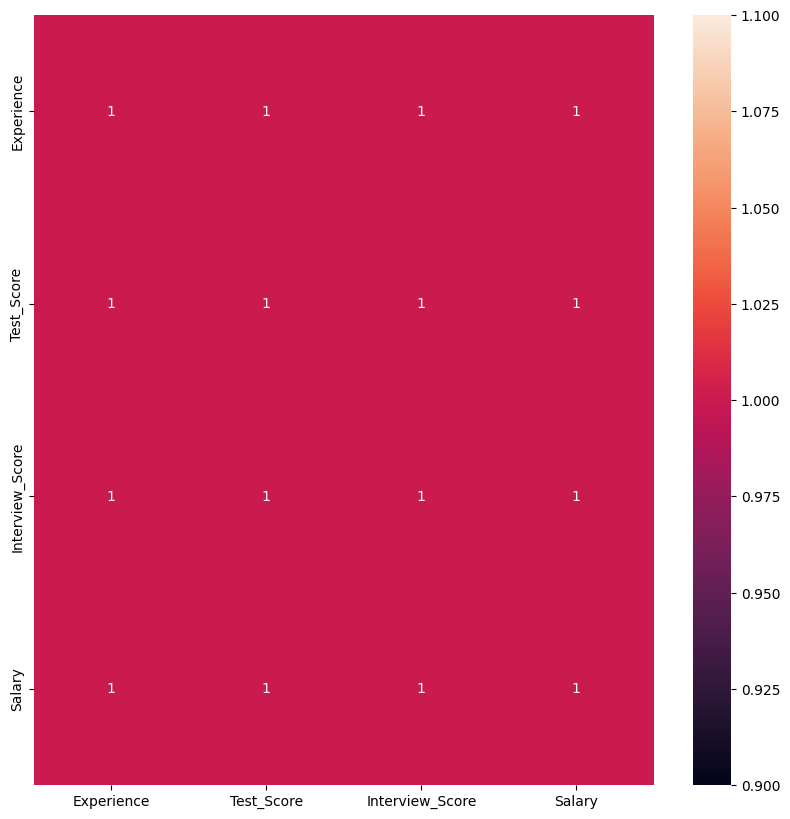

In [13]:
plt.figure(figsize = (10,10))
sns.heatmap(df.corr() , annot = True)
plt.show()

# boxplot :      
hear it showing no outliers in the data set

<Axes: >

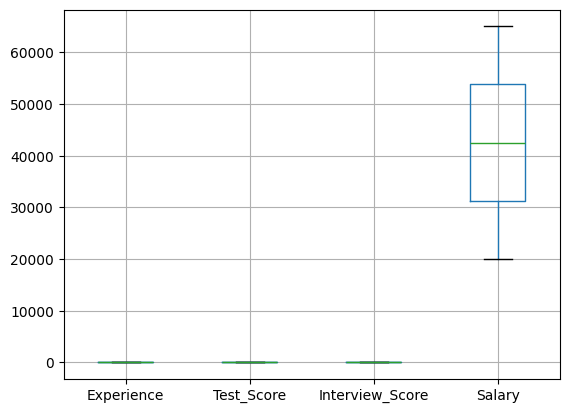

In [14]:
df.boxplot()

# Step 5 : Building Model

In [15]:
x = df.drop("Salary" , axis = 1)
y = df["Salary"]

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 32)


In [17]:
model = LinearRegression()
model.fit(x_train,y_train)


LinearRegression()

In [18]:
y_predict = model.predict(x_test)

# Evaluation matrices

In [19]:
rmse = np.sqrt(mean_squared_error(y_test,y_predict))
r2_score = r2_score(y_test,y_predict)


In [20]:
print(rmse)
print(r2_score)

1.0289757937229989e-11
1.0


# Multiple feature models

In [22]:
from sklearn.metrics import r2_score

X_multi = df[['Experience', 'Test_Score', 'Interview_Score']]

X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("Multiple Feature RMSE:", rmse_multi)
print("Multiple Feature R2:", r2_multi)

Multiple Feature RMSE: 5.1448789686149945e-12
Multiple Feature R2: 1.0


# Model Comparison

In [25]:
print("---- MODEL COMPARISON ----")
print(f"Single Feature -> RMSE: {rmse}, R2: {r2_score}")
print(f"Multiple Feature -> RMSE: {rmse_multi}, R2: {r2_multi}")

---- MODEL COMPARISON ----
Single Feature -> RMSE: 1.0289757937229989e-11, R2: <function r2_score at 0x7df06ff1aa20>
Multiple Feature -> RMSE: 5.1448789686149945e-12, R2: 1.0


# Test Model

In [27]:
sample = [[5, 70, 65]]
prediction = model.predict(sample)

print("Predicted Salary:", prediction[0])

Predicted Salary: 40000.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
